In [0]:
#%pip install ydata-profiling --no-deps


In [0]:
%pip install pandas matplotlib seaborn scipy tqdm pydantic jinja2 visions multimethod statsmodels typeguard imagehash wordcloud dacite


Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
dbutils.library.restartPython()

In [0]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from pyspark.sql import functions as F



In [0]:

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("seaborn:", sns.__version__)

print("All good — ready for EDA")


pandas: 2.2.3
numpy: 2.1.3
seaborn: 0.13.2
All good — ready for EDA


In [0]:
# Plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)



Free Version does not allow ydata-profiling in managed dependencies.So going for manual EDA

Insurance Fraud Analytics Platform
**Purpose:** Understand the raw data before any cleaning or modelling.  
Every decision made here (null strategy, feature selection, class imbalance handling) feeds directly into cleaning and modelling.

In [0]:
txn = spark.table("default.train_transaction")
idn = spark.table("default.train_identity")
porto = spark.table("default.train")

In [0]:
print("Transactions:", txn.count(), "rows,", len(txn.columns), "cols")


Transactions: 590540 rows, 394 cols


In [0]:
print("Identity    :", idn.count(), "rows,", len(idn.columns), "cols")


Identity    : 144233 rows, 41 cols


In [0]:
print("Porto       :", porto.count(), "rows,", len(porto.columns), "cols")

Porto       : 595212 rows, 59 cols


In [0]:
display(porto.limit(5))

id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,ps_ind_10_bin,ps_ind_11_bin,ps_ind_12_bin,ps_ind_13_bin,ps_ind_14,ps_ind_15,ps_ind_16_bin,ps_ind_17_bin,ps_ind_18_bin,ps_reg_01,ps_reg_02,ps_reg_03,ps_car_01_cat,ps_car_02_cat,ps_car_03_cat,ps_car_04_cat,ps_car_05_cat,ps_car_06_cat,ps_car_07_cat,ps_car_08_cat,ps_car_09_cat,ps_car_10_cat,ps_car_11_cat,ps_car_11,ps_car_12,ps_car_13,ps_car_14,ps_car_15,ps_calc_01,ps_calc_02,ps_calc_03,ps_calc_04,ps_calc_05,ps_calc_06,ps_calc_07,ps_calc_08,ps_calc_09,ps_calc_10,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
7,0,2,2,5,1,0,0,1,0,0,0,0,0,0,0,11,0,1,0,0.7,0.2,0.7180703307999999,10,1,-1,0,1,4,1,0,0,1,12,2,0.4,0.8836789178,0.3708099244,3.6055512755000003,0.6,0.5,0.2,3,1,10,1,10,1,5,9,1,5,8,0,1,1,0,0,1
9,0,1,1,7,0,0,0,0,1,0,0,0,0,0,0,3,0,0,1,0.8,0.4,0.7660776723,11,1,-1,0,-1,11,1,1,2,1,19,3,0.316227766,0.6188165191,0.3887158345,2.4494897428,0.3,0.1,0.3,2,1,9,5,8,1,7,3,1,1,9,0,1,1,0,1,0
13,0,5,4,9,1,0,0,0,1,0,0,0,0,0,0,12,1,0,0,0.0,0.0,-1.0,7,1,-1,0,-1,14,1,1,2,1,60,1,0.316227766,0.6415857163,0.34727510710000004,3.3166247904,0.5,0.7,0.1,2,2,9,1,8,2,7,4,2,7,7,0,1,1,0,1,0
16,0,0,1,2,0,0,1,0,0,0,0,0,0,0,0,8,1,0,0,0.9,0.2,0.5809475019,7,1,0,0,1,11,1,1,3,1,104,1,0.3741657387,0.5429487899000001,0.2949576241,2.0,0.6,0.9,0.1,2,4,7,1,8,4,2,2,2,4,9,0,0,0,0,0,0
17,0,0,2,0,1,0,1,0,0,0,0,0,0,0,0,9,1,0,0,0.7,0.6,0.840758586,11,1,-1,0,-1,14,1,1,2,1,82,3,0.3160696126,0.5658315025,0.3651027253,2.0,0.4,0.6,0.0,2,2,6,3,10,2,12,3,1,1,3,0,0,0,1,1,0


In [0]:
porto_pdf = porto.sample(fraction=0.1, seed=42).toPandas()

In [0]:
porto_pdf.shape

(59660, 59)

In [0]:
porto_pdf.dtypes

id                  int64
target              int64
ps_ind_01           int64
ps_ind_02_cat       int64
ps_ind_03           int64
ps_ind_04_cat       int64
ps_ind_05_cat       int64
ps_ind_06_bin       int64
ps_ind_07_bin       int64
ps_ind_08_bin       int64
ps_ind_09_bin       int64
ps_ind_10_bin       int64
ps_ind_11_bin       int64
ps_ind_12_bin       int64
ps_ind_13_bin       int64
ps_ind_14           int64
ps_ind_15           int64
ps_ind_16_bin       int64
ps_ind_17_bin       int64
ps_ind_18_bin       int64
ps_reg_01         float64
ps_reg_02         float64
ps_reg_03         float64
ps_car_01_cat       int64
ps_car_02_cat       int64
ps_car_03_cat       int64
ps_car_04_cat       int64
ps_car_05_cat       int64
ps_car_06_cat       int64
ps_car_07_cat       int64
ps_car_08_cat       int64
ps_car_09_cat       int64
ps_car_10_cat       int64
ps_car_11_cat       int64
ps_car_11           int64
ps_car_12         float64
ps_car_13         float64
ps_car_14         float64
ps_car_15   

In [0]:
porto_pdf.describe(include="all")

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,ps_ind_10_bin,ps_ind_11_bin,ps_ind_12_bin,ps_ind_13_bin,ps_ind_14,ps_ind_15,ps_ind_16_bin,ps_ind_17_bin,ps_ind_18_bin,ps_reg_01,ps_reg_02,ps_reg_03,ps_car_01_cat,ps_car_02_cat,ps_car_03_cat,ps_car_04_cat,ps_car_05_cat,ps_car_06_cat,ps_car_07_cat,ps_car_08_cat,ps_car_09_cat,ps_car_10_cat,ps_car_11_cat,ps_car_11,ps_car_12,ps_car_13,ps_car_14,ps_car_15,ps_calc_01,ps_calc_02,ps_calc_03,ps_calc_04,ps_calc_05,ps_calc_06,ps_calc_07,ps_calc_08,ps_calc_09,ps_calc_10,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
count,5.966000e+04,59660.000000,59660.00000,59660.000000,59660.000000,59660.000000,59660.000000,59660.000000,59660.000000,59660.000000,59660.000000,59660.000000,59660.000000,59660.000000,59660.000000,59660.000000,59660.000000,59660.000000,59660.000000,59660.000000,59660.000000,59660.000000,59660.000000,59660.000000,59660.000000,59660.000000,59660.000000,59660.000000,59660.000000,59660.000000,59660.000000,59660.000000,59660.00000,59660.00000,59660.000000,59660.000000,59660.000000,59660.000000,59660.000000,59660.000000,59660.000000,59660.000000,59660.000000,59660.000000,59660.000000,59660.000000,59660.000000,59660.000000,59660.000000,59660.000000,59660.000000,59660.000000,59660.000000,59660.000000,59660.000000,59660.000000,59660.000000,59660.00000,59660.000000
mean,7.443702e+05,0.037144,1.89524,1.357224,4.437446,0.417549,0.406856,0.392591,0.258548,0.163979,0.184881,0.000436,0.001609,0.008984,0.000872,0.011901,7.291301,0.663393,0.120634,0.151861,0.607953,0.436458,0.549074,8.295910,0.828377,-0.508515,0.725109,-0.154811,6.545793,0.909403,0.830791,1.326366,0.99244,62.23587,2.351643,0.380112,0.813360,0.279517,3.067095,0.447985,0.448807,0.449712,2.373567,1.884831,7.690597,3.005146,9.220047,2.329182,8.427405,5.437915,1.431277,2.875595,7.520399,0.121639,0.625930,0.552581,0.287764,0.34891,0.152497
std,4.297778e+05,0.189116,1.98860,0.663513,2.699719,0.493499,1.351184,0.488331,0.437841,0.370260,0.388204,0.020872,0.040082,0.094359,0.029510,0.123610,3.542002,0.472553,0.325704,0.358889,0.287730,0.405264,0.795971,2.503395,0.377055,0.786550,2.151193,0.846825,5.489600,0.347431,0.374939,0.977772,0.09059,33.10091,0.830997,0.058422,0.223585,0.352265,0.730984,0.287519,0.286276,0.287211,1.117311,1.137062,1.337734,1.411731,1.459909,1.244241,2.888644,2.334830,1.197611,1.693134,2.743822,0.326871,0.483886,0.497232,0.452724,0.47663,0.359505
min,7.000000e+00,0.000000,0.00000,-1.000000,0.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,0.000000,-1.000000,0.000000,-1.000000,0.000000,-1.000000,0.000000,-1.000000,0.00000,1.00000,0.000000,0.141421,0.308723,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,3.717602e+05,0.000000,0.00000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.000000,0.000000,0.000000,0.400000,0.200000,0.524404,7.000000,1.000000,-1.000000,0.000000,-1.000000,1.000000,1.000000,1.000000,0.000000,1.00000,32.00000,2.000000,0.316228,0.672067,0.334813,2.828427,0.200000,0.200000,0.200000,2.000000,1.000000,7.000000,2.000000,8.000000,1.000000,6.000000,4.000000,1.000000,2.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
50%,7.463375e+05,0.000000,1.00000,1.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.000000,1.000000,0.000000,0.000000,0.700000,0.300000,0.719375,7.000000,1.000000,-1.000000,0.000000,0.000000,7.000000,1.000000,1.000000,2.000000,1.00000,65.00000,3.000000,0.374166,0.765501,0.368782

In [0]:
porto_pdf.isnull().mean().sort_values(ascending=False).head(20)

id               0.0
ps_calc_06       0.0
ps_car_10_cat    0.0
ps_car_11_cat    0.0
ps_car_11        0.0
ps_car_12        0.0
ps_car_13        0.0
ps_car_14        0.0
ps_car_15        0.0
ps_calc_01       0.0
ps_calc_02       0.0
ps_calc_03       0.0
ps_calc_04       0.0
ps_calc_05       0.0
ps_calc_07       0.0
ps_car_08_cat    0.0
ps_calc_08       0.0
ps_calc_09       0.0
ps_calc_10       0.0
ps_calc_11       0.0
dtype: float64

In [0]:
txn.printSchema()


root
 |-- TransactionID: long (nullable = true)
 |-- isFraud: long (nullable = true)
 |-- TransactionDT: long (nullable = true)
 |-- TransactionAmt: double (nullable = true)
 |-- ProductCD: string (nullable = true)
 |-- card1: long (nullable = true)
 |-- card2: double (nullable = true)
 |-- card3: double (nullable = true)
 |-- card4: string (nullable = true)
 |-- card5: double (nullable = true)
 |-- card6: string (nullable = true)
 |-- addr1: double (nullable = true)
 |-- addr2: double (nullable = true)
 |-- dist1: double (nullable = true)
 |-- dist2: double (nullable = true)
 |-- P_emaildomain: string (nullable = true)
 |-- R_emaildomain: string (nullable = true)
 |-- C1: double (nullable = true)
 |-- C2: double (nullable = true)
 |-- C3: double (nullable = true)
 |-- C4: double (nullable = true)
 |-- C5: double (nullable = true)
 |-- C6: double (nullable = true)
 |-- C7: double (nullable = true)
 |-- C8: double (nullable = true)
 |-- C9: double (nullable = true)
 |-- C10: double (nul

In [0]:
idn.printSchema()


root
 |-- TransactionID: long (nullable = true)
 |-- id_01: double (nullable = true)
 |-- id_02: double (nullable = true)
 |-- id_03: double (nullable = true)
 |-- id_04: double (nullable = true)
 |-- id_05: double (nullable = true)
 |-- id_06: double (nullable = true)
 |-- id_07: double (nullable = true)
 |-- id_08: double (nullable = true)
 |-- id_09: double (nullable = true)
 |-- id_10: double (nullable = true)
 |-- id_11: double (nullable = true)
 |-- id_12: string (nullable = true)
 |-- id_13: double (nullable = true)
 |-- id_14: double (nullable = true)
 |-- id_15: string (nullable = true)
 |-- id_16: string (nullable = true)
 |-- id_17: double (nullable = true)
 |-- id_18: double (nullable = true)
 |-- id_19: double (nullable = true)
 |-- id_20: double (nullable = true)
 |-- id_21: double (nullable = true)
 |-- id_22: double (nullable = true)
 |-- id_23: string (nullable = true)
 |-- id_24: double (nullable = true)
 |-- id_25: double (nullable = true)
 |-- id_26: double (nullabl

In [0]:
porto.printSchema()

root
 |-- id: long (nullable = true)
 |-- target: long (nullable = true)
 |-- ps_ind_01: long (nullable = true)
 |-- ps_ind_02_cat: long (nullable = true)
 |-- ps_ind_03: long (nullable = true)
 |-- ps_ind_04_cat: long (nullable = true)
 |-- ps_ind_05_cat: long (nullable = true)
 |-- ps_ind_06_bin: long (nullable = true)
 |-- ps_ind_07_bin: long (nullable = true)
 |-- ps_ind_08_bin: long (nullable = true)
 |-- ps_ind_09_bin: long (nullable = true)
 |-- ps_ind_10_bin: long (nullable = true)
 |-- ps_ind_11_bin: long (nullable = true)
 |-- ps_ind_12_bin: long (nullable = true)
 |-- ps_ind_13_bin: long (nullable = true)
 |-- ps_ind_14: long (nullable = true)
 |-- ps_ind_15: long (nullable = true)
 |-- ps_ind_16_bin: long (nullable = true)
 |-- ps_ind_17_bin: long (nullable = true)
 |-- ps_ind_18_bin: long (nullable = true)
 |-- ps_reg_01: double (nullable = true)
 |-- ps_reg_02: double (nullable = true)
 |-- ps_reg_03: double (nullable = true)
 |-- ps_car_01_cat: long (nullable = true)
 |-

In [0]:
txn.columns

['TransactionID',
 'isFraud',
 'TransactionDT',
 'TransactionAmt',
 'ProductCD',
 'card1',
 'card2',
 'card3',
 'card4',
 'card5',
 'card6',
 'addr1',
 'addr2',
 'dist1',
 'dist2',
 'P_emaildomain',
 'R_emaildomain',
 'C1',
 'C2',
 'C3',
 'C4',
 'C5',
 'C6',
 'C7',
 'C8',
 'C9',
 'C10',
 'C11',
 'C12',
 'C13',
 'C14',
 'D1',
 'D2',
 'D3',
 'D4',
 'D5',
 'D6',
 'D7',
 'D8',
 'D9',
 'D10',
 'D11',
 'D12',
 'D13',
 'D14',
 'D15',
 'M1',
 'M2',
 'M3',
 'M4',
 'M5',
 'M6',
 'M7',
 'M8',
 'M9',
 'V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'V29',
 'V30',
 'V31',
 'V32',
 'V33',
 'V34',
 'V35',
 'V36',
 'V37',
 'V38',
 'V39',
 'V40',
 'V41',
 'V42',
 'V43',
 'V44',
 'V45',
 'V46',
 'V47',
 'V48',
 'V49',
 'V50',
 'V51',
 'V52',
 'V53',
 'V54',
 'V55',
 'V56',
 'V57',
 'V58',
 'V59',
 'V60',
 'V61',
 'V62',
 'V63',
 'V64',
 'V

In [0]:
display(txn.select("isFraud").limit(10))

isFraud
0
0
0
0
0
0
0
0
0
0


In [0]:
porto.columns

['id',
 'target',
 'ps_ind_01',
 'ps_ind_02_cat',
 'ps_ind_03',
 'ps_ind_04_cat',
 'ps_ind_05_cat',
 'ps_ind_06_bin',
 'ps_ind_07_bin',
 'ps_ind_08_bin',
 'ps_ind_09_bin',
 'ps_ind_10_bin',
 'ps_ind_11_bin',
 'ps_ind_12_bin',
 'ps_ind_13_bin',
 'ps_ind_14',
 'ps_ind_15',
 'ps_ind_16_bin',
 'ps_ind_17_bin',
 'ps_ind_18_bin',
 'ps_reg_01',
 'ps_reg_02',
 'ps_reg_03',
 'ps_car_01_cat',
 'ps_car_02_cat',
 'ps_car_03_cat',
 'ps_car_04_cat',
 'ps_car_05_cat',
 'ps_car_06_cat',
 'ps_car_07_cat',
 'ps_car_08_cat',
 'ps_car_09_cat',
 'ps_car_10_cat',
 'ps_car_11_cat',
 'ps_car_11',
 'ps_car_12',
 'ps_car_13',
 'ps_car_14',
 'ps_car_15',
 'ps_calc_01',
 'ps_calc_02',
 'ps_calc_03',
 'ps_calc_04',
 'ps_calc_05',
 'ps_calc_06',
 'ps_calc_07',
 'ps_calc_08',
 'ps_calc_09',
 'ps_calc_10',
 'ps_calc_11',
 'ps_calc_12',
 'ps_calc_13',
 'ps_calc_14',
 'ps_calc_15_bin',
 'ps_calc_16_bin',
 'ps_calc_17_bin',
 'ps_calc_18_bin',
 'ps_calc_19_bin',
 'ps_calc_20_bin']

Next step to convert to Pandas
txn is a big table so, will take a sample of it to test 

In [0]:
sample_txn = txn.limit(10000).toPandas()


In [0]:
sample_txn.memory_usage(deep=True).sum() / (1024**2)

np.float64(34.332343101501465)

In [0]:
estimated_full_mb = (sample_txn.memory_usage(deep=True).sum() / (1024**2)) * (txn.count() / len(sample_txn))
print(estimated_full_mb)

2027.4621895160676


train transaction table is not safe to convert to pandas as the entire table will take 2GB memory.
So EDA will be done using sample of 10% table of all 3 datasets.

In [0]:
df_txn = txn.sample(fraction=0.1, seed=42).toPandas()

In [0]:
df_idn = idn.sample(fraction=0.1, seed=42).toPandas()


In [0]:
df_porto = porto.sample(fraction=0.1, seed=42).toPandas()


Next step : Find out **Fraud rate and claim rate** to find out how rare is the positive class?
If only a small percentage of records are positive, then the data is imbalanced.
  50% fraud rate, that would be unrealistic for most fraud settings.
  3% to 5% positive class, that would be realistic.

IEEE-CIS fraud rate = percentage of rows where isFraud = 1
Porto Seguro claim rate = percentage of rows where target = 1

That matters because , normal accuracy becomes misleading and model may just predict the majority class.
In that case special methods need to utilized like:
-   class weights
-   SMOTE
-   threshold tuning
-   precision-recall evaluation

So this step directly helps your modeling plan.

In [0]:
print(type(df_txn))

<class 'pandas.core.frame.DataFrame'>


In [0]:
print("isFraud" in df_txn.columns)
print(df_txn.columns.tolist())

True
['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81

In [0]:
fraud_rate_pct = round(df_txn["isFraud"].mean() * 100, 4) 
fraud_count = int(df_txn["isFraud"].sum())

print(f"Fraud rate (IEEE-CIS): {fraud_rate_pct}%")
print(f"Fraud count: {fraud_count}")

Fraud rate (IEEE-CIS): 3.4666%
Fraud count: 2042


In [0]:
claim_rate_pct = round(df_porto["target"].mean() * 100, 4)
claim_count = int(df_porto["target"].sum())


print(f"Claim rate (Porto Seguro): {claim_rate_pct}%")
print(f"Claim count: {claim_count}")

Claim rate (Porto Seguro): 3.7144%
Claim count: 2216


Both datasets have a low positive-class rate, which means they are imbalanced classification problems.
This is generally expected in fraud/risk prediction:
  most records are non-fraud / normal
  only a small minority are fraud / positive target
For a sample of 10% of the complete dataset 
  2042 is the fraud count in the sample, not in the full IEEE-CIS dataset.
  2216 is the positive claim count in the sample, not in the full Porto dataset.

The sampled IEEE-CIS and Porto Seguro datasets show positive-class rates of approximately 3.47% and 3.71%, respectively. This confirms that both datasets are class-imbalanced, which is consistent with real-world fraud and risk prediction settings where fraudulent or suspicious cases are relatively rare.

This class imbalance is important because it affects model design and evaluation. It suggests that later stages should consider imbalance-aware methods such as resampling, class weighting, and metrics like precision, recall, F1, and ROC-AUC rather than relying only on accuracy.

These findings help justify:
  using SMOTE or another imbalance strategy later
  not trusting accuracy alone
  using fraud triage logic carefully


Next step Trasaction amount Distribution 

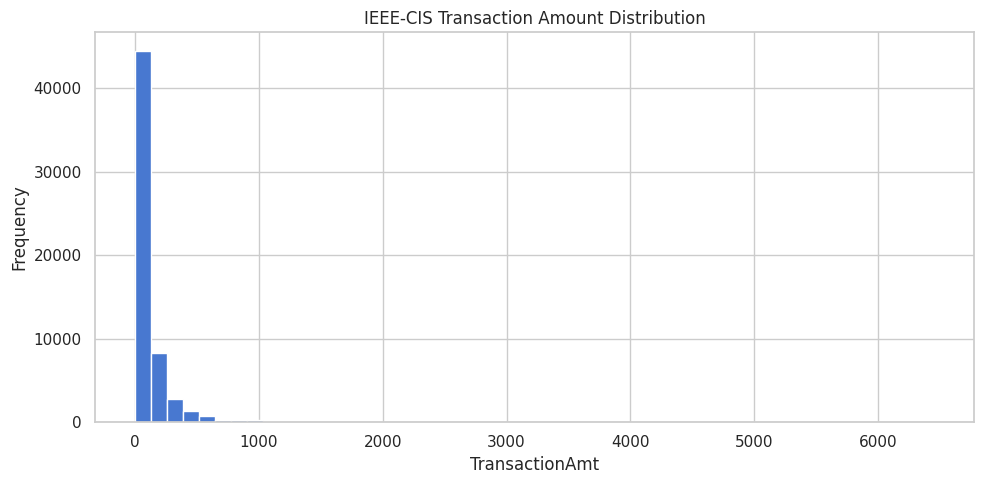

In [0]:
plt.figure(figsize=(10, 5))
df_txn["TransactionAmt"].dropna().plot(kind="hist", bins=50)
plt.title("IEEE-CIS Transaction Amount Distribution")
plt.xlabel("TransactionAmt")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

This above plots the full transaction amount distribution.
If TransactionAmt has a few very large values, those extreme values stretch the x-axis far to the right.
  most normal transaction amounts get squeezed into the left side
  the histogram bars near the lower values become compressed
  the real shape of the majority of data is harder to see

From the full histogram:
  the feature has a long right tail
  there are high-value outliers
  the distribution is not normal

The below clipped plot caps all values above the 99th percentile at the 99th percentile value.
  the top 1% extreme values are no longer stretching the axis
  the histogram focuses more on the bulk of the data
  the main shape becomes easier to interpret
This does not delete rows.It only limits how high the extreme values appear in the plotted series.

view for skew:

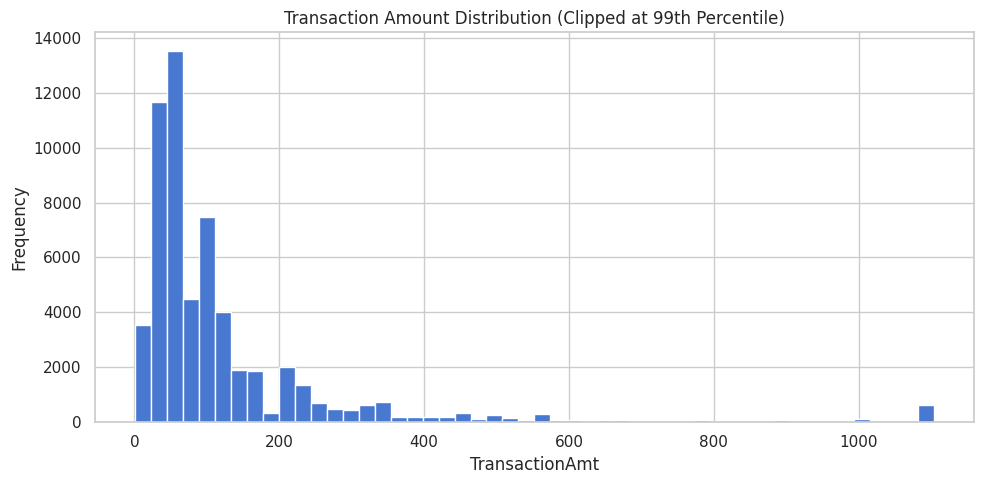

In [0]:
plt.figure(figsize=(10, 5))
df_txn["TransactionAmt"].dropna().clip(
    upper=df_txn["TransactionAmt"].quantile(0.99)
).plot(kind="hist", bins=50)
plt.title("Transaction Amount Distribution (Clipped at 99th Percentile)")
plt.xlabel("TransactionAmt")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

From the clipped histogram:
  most transactions fall in a much lower range
  the variable is still skewed, but the central pattern is easier to inspect
  the outliers are influencing the raw distribution strongly

The raw TransactionAmt histogram is strongly right-skewed, with a small number of very large values stretching the distribution. To better visualize the main concentration of transaction amounts, a second histogram was plotted after clipping values above the 99th percentile. This makes the bulk of the distribution easier to interpret while still indicating the presence of extreme high-value transactions.

The comparison suggests that TransactionAmt contains outliers and is not normally distributed, which supports considering a log transformation or other skew-handling approach during feature engineering.

Next Step: **IEEE-CIS null strategy table**

  column > 70% null : drop
  otherwise null columns → impute

In [0]:
null_pct = (df_txn.isnull().mean() * 100).round(2)

null_df = (
    null_pct[null_pct > 0]
    .reset_index()
    .rename(columns={"index": "column", 0: "null_pct"})
)

null_df["dtype"] = null_df["column"].map(df_txn.dtypes.astype(str).to_dict())
null_df["null_count"] = null_df["column"].map(df_txn.isnull().sum().to_dict())

def assign_null_strategy(pct):
    if pct > 70:
        return "Drop"
    return "Impute"

null_df["strategy"] = null_df["null_pct"].apply(assign_null_strategy)
null_df = null_df.sort_values("null_pct", ascending=False).reset_index(drop=True)

display(null_df.head(30))

column,null_pct,dtype,null_count,strategy
D7,93.68,float64,55185,Drop
dist2,93.64,float64,55158,Drop
D13,89.67,float64,52822,Drop
D14,89.58,float64,52767,Drop
D12,89.24,float64,52567,Drop
D6,87.82,float64,51733,Drop
D9,87.4,float64,51481,Drop
D8,87.4,float64,51481,Drop
V147,85.96,float64,50634,Drop
V150,85.96,float64,50634,Drop


Drop and impute column lists

In [0]:
drop_cols = null_df.loc[null_df["strategy"] == "Drop", "column"].tolist()
impute_cols = null_df.loc[null_df["strategy"] == "Impute", "column"].tolist()

print("Columns to drop   :", len(drop_cols))
print("Columns to impute :", len(impute_cols))

Columns to drop   : 168
Columns to impute : 174


Categorical columns analysis (IEEE-CIS)

In [0]:
cat_cols = df_txn.select_dtypes(include=["object"]).columns.tolist()

print("Categorical column count:", len(cat_cols))
print("Categorical columns:")
print(cat_cols)

Categorical column count: 14
Categorical columns:
['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']


Fraud rate by selected categorical features:

In [0]:
for col in ["ProductCD", "card4", "card6", "P_emaildomain", "R_emaildomain"]:
    if col in df_txn.columns:
        print(f"\nFraud rate by {col}")
        print(
            df_txn.groupby(col)["isFraud"]
            .mean()
            .sort_values(ascending=False)
            .head(10)
        )


Fraud rate by ProductCD
ProductCD
C    0.111626
S    0.062393
H    0.050061
R    0.038560
W    0.020708
Name: isFraud, dtype: float64

Fraud rate by card4
card4
discover            0.071221
american express    0.043035
visa                0.034912
mastercard          0.032531
Name: isFraud, dtype: float64

Fraud rate by card6
card6
credit             0.067097
debit              0.023721
charge card        0.000000
debit or credit    0.000000
Name: isFraud, dtype: float64

Fraud rate by P_emaildomain
P_emaildomain
mail.com          0.215385
aim.com           0.125000
mac.com           0.083333
outlook.com       0.077551
outlook.es        0.071429
embarqmail.com    0.058824
hotmail.com       0.047461
gmail.com         0.045607
live.com.mx       0.043478
cox.net           0.035971
Name: isFraud, dtype: float64

Fraud rate by R_emaildomain
R_emaildomain
protonmail.com    1.000000
earthlink.net     0.333333
mail.com          0.285714
outlook.com       0.125000
gmail.com         0.122055
ic

Porto Seguro null check

In [0]:
porto_null_pct = (df_porto.isnull().mean() * 100).round(2)

porto_null_df = (
    porto_null_pct[porto_null_pct > 0]
    .reset_index()
    .rename(columns={"index": "column", 0: "null_pct"})
)

porto_null_df["dtype"] = porto_null_df["column"].map(df_porto.dtypes.astype(str).to_dict())
porto_null_df["null_count"] = porto_null_df["column"].map(df_porto.isnull().sum().to_dict())
porto_null_df = porto_null_df.sort_values("null_pct", ascending=False).reset_index(drop=True)

print("Porto columns with nulls:", len(porto_null_df))
print(porto_null_df)

Porto columns with nulls: 0
Empty DataFrame
Columns: [column, null_pct, dtype, null_count]
Index: []


No true null values were detected in the sampled Porto Seguro dataset. This suggests that missing or unknown information is not represented using standard nulls, but likely through encoded placeholder values such as -1. Therefore, additional checks for encoded missingness are necessary before preprocessing.

- for IEEE-CIS → handle real nulls
- for Porto Seguro → check encoded missing values like -1

Next step : **Porto Seguro** -1 encoded missing/unknown check

In [0]:
porto_minus1_summary = []

for col in df_porto.columns:
    try:
        minus1_count = int((df_porto[col] == -1).sum())
        if minus1_count > 0:
            porto_minus1_summary.append({
                "column": col,
                "minus1_count": minus1_count,
                "minus1_pct": round((minus1_count / len(df_porto)) * 100, 2)
            })
    except Exception:
        pass

porto_minus1_df = pd.DataFrame(porto_minus1_summary).sort_values(
    "minus1_pct", ascending=False
).reset_index(drop=True)

display(porto_minus1_df.head(30))

column,minus1_count,minus1_pct
ps_car_03_cat,41337,69.29
ps_car_05_cat,26724,44.79
ps_reg_03,10885,18.25
ps_car_14,4142,6.94
ps_car_07_cat,1143,1.92
ps_ind_05_cat,581,0.97
ps_car_09_cat,67,0.11
ps_ind_02_cat,26,0.04
ps_ind_04_cat,10,0.02
ps_car_01_cat,14,0.02


**Null heatmap** for key IEEE-CIS columns

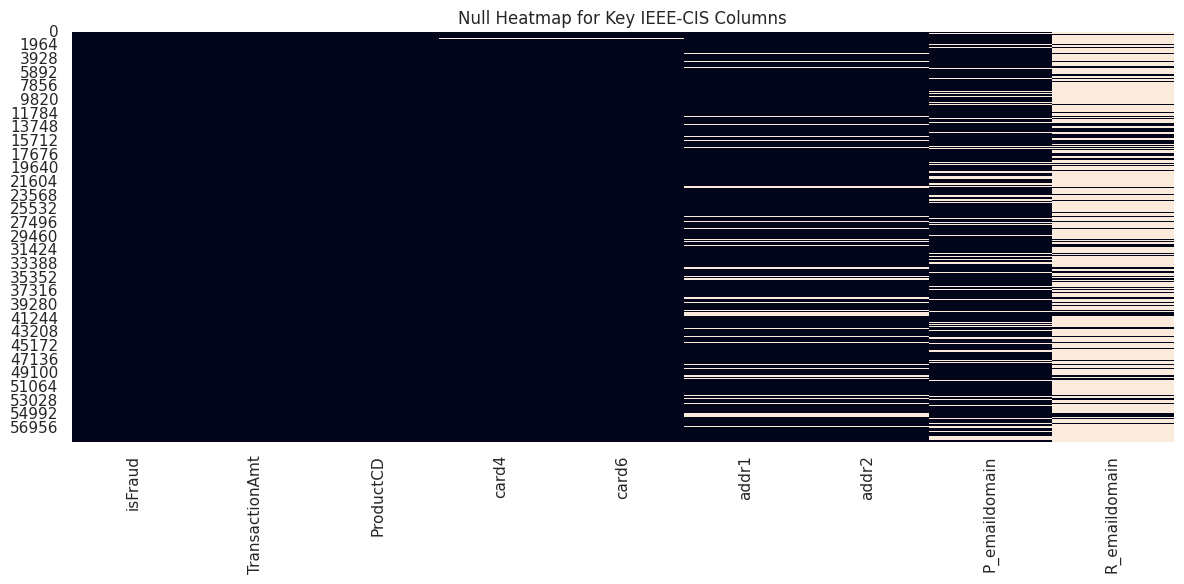

In [0]:
key_cols = [
    "isFraud", "TransactionAmt", "ProductCD", "card4", "card6",
    "addr1", "addr2", "P_emaildomain", "R_emaildomain"
]
key_cols = [c for c in key_cols if c in df_txn.columns]

plt.figure(figsize=(12, 6))
sns.heatmap(df_txn[key_cols].isnull(), cbar=False)
plt.title("Null Heatmap for Key IEEE-CIS Columns")
plt.tight_layout()
plt.show()

<Axes: >

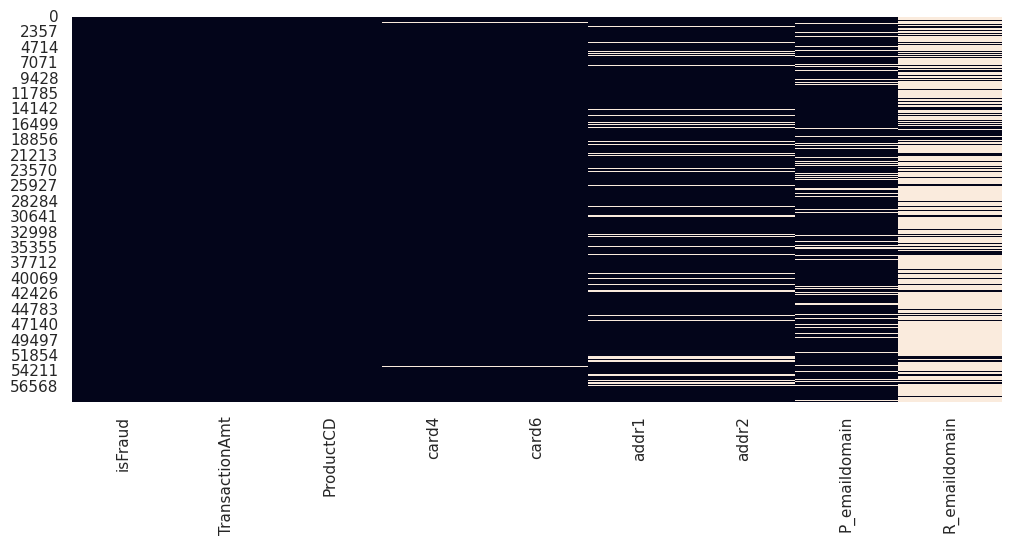

In [0]:
sns.heatmap(df_txn[key_cols].isnull(), cbar=False)

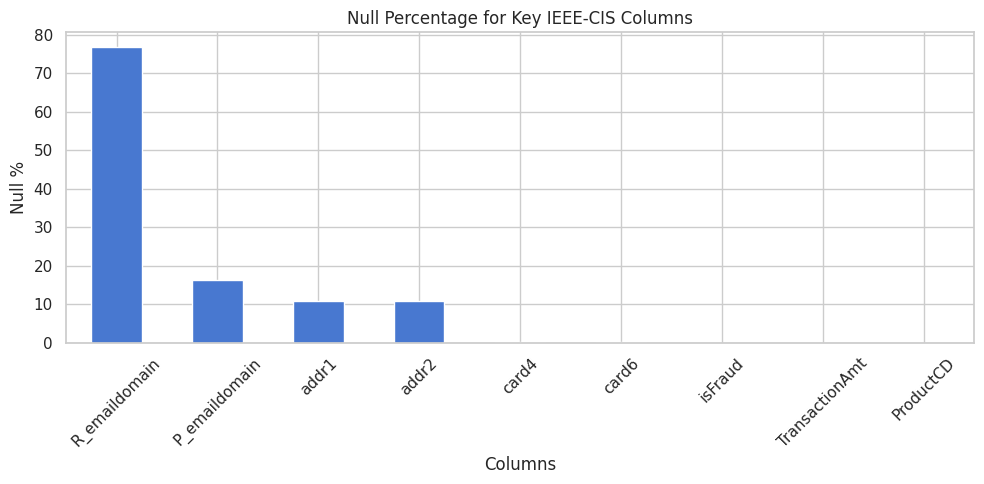

In [0]:
null_pct_key = (df_txn[key_cols].isnull().mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
null_pct_key.plot(kind="bar")
plt.title("Null Percentage for Key IEEE-CIS Columns")
plt.ylabel("Null %")
plt.xlabel("Columns")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

A column-wise null percentage chart was used instead of a row-level heatmap because the heatmap became too dense for interpretation on sampled transaction data. The bar chart provides a clearer view of which key fields have missing data and supports decisions on dropping or imputing columns.

Key EDA observations for notebook output

In [0]:
print("Key EDA Findings Summary:")
print(f"1. IEEE-CIS transaction sample fraud rate is {fraud_rate_pct}% -> confirms class imbalance.")
print(f"2. IEEE-CIS transaction columns to drop (>70% null): {len(drop_cols)}")
print(f"3. IEEE-CIS transaction columns to impute: {len(impute_cols)}")
print(f"4. Porto Seguro columns with -1 encoding: {len(porto_minus1_df)}")
print("5. IEEE-CIS TransactionAmt appears right-skewed.")
print("6. IEEE-CIS categorical features such as ProductCD and card4 should be reviewed as potentially useful signals.")

Key EDA Findings Summary:
1. IEEE-CIS transaction sample fraud rate is 3.4666% -> confirms class imbalance.
2. IEEE-CIS transaction columns to drop (>70% null): 168
3. IEEE-CIS transaction columns to impute: 174
4. Porto Seguro columns with -1 encoding: 10
5. IEEE-CIS TransactionAmt appears right-skewed.
6. IEEE-CIS categorical features such as ProductCD and card4 should be reviewed as potentially useful signals.


EDA Summary in json format

In [0]:
import json
from datetime import datetime

summary = {
    "generated_at": datetime.now().isoformat(),
    "ieee_cis": {
        "table": "default.train_transaction",
        "sample_rows": len(df_txn),
        "total_columns_in_sample": df_txn.shape[1],
        "sample_fraud_rate_pct": round(df_txn["isFraud"].mean() * 100, 4),
        "sample_fraud_count": int(df_txn["isFraud"].sum()),
        "sample_null_cols_total": len(null_df),
        "sample_cols_to_drop_gt70_null": len(drop_cols),
        "sample_cols_to_impute": len(impute_cols),
        "categorical_cols": cat_cols
    },
    "porto_seguro": {
        "table": "default.porto_train",
        "sample_rows": len(df_porto),
        "total_columns_in_sample": df_porto.shape[1],
        "sample_claim_rate_pct": round(df_porto["target"].mean() * 100, 4),
        "sample_claim_count": int(df_porto["target"].sum()),
        "sample_true_null_cols": len(porto_null_df),
        "sample_minus1_encoded_cols": len(porto_minus1_df)
    },
    "key_findings": [
        f"IEEE-CIS sample fraud rate is {round(df_txn['isFraud'].mean() * 100, 4)}%, confirming class imbalance.",
        f"IEEE-CIS sample columns to drop (>70% null): {len(drop_cols)}.",
        f"IEEE-CIS sample columns to impute: {len(impute_cols)}.",
        f"Porto Seguro sample columns with -1 encoding: {len(porto_minus1_df)}.",
        "IEEE-CIS TransactionAmt appears right-skewed.",
        "IEEE-CIS categorical features such as ProductCD and card4 appear potentially informative in the sample."
    ]
}

summary_json = json.dumps(summary, indent=2)
print(summary_json)

{
  "generated_at": "2026-04-01T15:56:04.643884",
  "ieee_cis": {
    "table": "default.train_transaction",
    "sample_rows": 58905,
    "total_columns_in_sample": 394,
    "sample_fraud_rate_pct": 3.4666,
    "sample_fraud_count": 2042,
    "sample_null_cols_total": 342,
    "sample_cols_to_drop_gt70_null": 168,
    "sample_cols_to_impute": 174,
    "categorical_cols": [
      "ProductCD",
      "card4",
      "card6",
      "P_emaildomain",
      "R_emaildomain",
      "M1",
      "M2",
      "M3",
      "M4",
      "M5",
      "M6",
      "M7",
      "M8",
      "M9"
    ]
  },
  "porto_seguro": {
    "table": "default.porto_train",
    "sample_rows": 59660,
    "total_columns_in_sample": 59,
    "sample_claim_rate_pct": 3.7144,
    "sample_claim_count": 2216,
    "sample_true_null_cols": 0,
    "sample_minus1_encoded_cols": 10
  },
  "key_findings": [
    "IEEE-CIS sample fraud rate is 3.4666%, confirming class imbalance.",
    "IEEE-CIS sample columns to drop (>70% null): 168.",


In [0]:
import os

print("Current working directory:", os.getcwd())

with open("eda_summary.json", "w") as f:
    f.write(summary_json)

print("Saved eda_summary.json successfully.")
print("File exists:", os.path.exists("eda_summary.json"))
print("Absolute path:", os.path.abspath("eda_summary.json"))

Current working directory: /Workspace/Users/nibedita.iter03@gmail.com
Saved eda_summary.json successfully.
File exists: True
Absolute path: /Workspace/Users/nibedita.iter03@gmail.com/eda_summary.json


In [0]:
with open("eda_summary.json", "r") as f:
    saved_text = f.read()

print(saved_text[:500])

{
  "generated_at": "2026-04-01T15:56:04.643884",
  "ieee_cis": {
    "table": "default.train_transaction",
    "sample_rows": 58905,
    "total_columns_in_sample": 394,
    "sample_fraud_rate_pct": 3.4666,
    "sample_fraud_count": 2042,
    "sample_null_cols_total": 342,
    "sample_cols_to_drop_gt70_null": 168,
    "sample_cols_to_impute": 174,
    "categorical_cols": [
      "ProductCD",
      "card4",
      "card6",
      "P_emaildomain",
      "R_emaildomain",
      "M1",
      "M2",
     


False


In [0]:
output_path = "/dbfs/FileStore/eda_summary.json"

with open(output_path, "w") as f:
    f.write(summary_json)

print(f"Saved to: {output_path}")

---------------------------------------------------------------------------
OSError                                   Traceback (most recent call last)
File <command-4987085490040662>, line 3
      1 output_path = "/dbfs/FileStore/eda_summary.json"
----> 3 with open(output_path, "w") as f:
      4     f.write(summary_json)
      6 print(f"Saved to: {output_path}")

File /databricks/python/lib/python3.12/site-packages/IPython/core/interactiveshell.py:324, in _modified_open(file, *args, **kwargs)
    317 if file in {0, 1, 2}:
    318     raise ValueError(
    319         f"IPython won't let you open fd={file} by default "
    320         "as it is likely to crash IPython. If you know what you are doing, "
    321         "you can use builtins' open."
    322     )
--> 324 return io_open(file, *args, **kwargs)

OSError: [Errno 5] Input/output error: '/dbfs/FileStore/eda_summary.json'

Final line :
Manual EDA was performed on a 10% sample of the IEEE-CIS transaction table for visualization and exploratory analysis, while exact dataset statistics such as row counts and overall class imbalance were verified from the full table.
